# 01 — Exploratory Data Analysis
**Dataset:** UCI Household Electric Power Consumption  
**Goal:** Understand the data before touching any model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.float_format', '{:.3f}'.format)

## 1. Load data

In [2]:
# separator is ';' and missing values are encoded as '?'
df = pd.read_csv(
    '../data/raw/household_power_consumption.txt',
    sep=';',
    na_values='?',
    low_memory=False
)

print(f'Shape: {df.shape}')
print(f'Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}')

Shape: (2075259, 9)
Rows: 2,075,259  |  Columns: 9


## 2. Basic info

In [3]:
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.000
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.000
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.000
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.000
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.000


In [4]:
df.dtypes

Date                      object
Time                      object
Global_active_power      float64
Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
Sub_metering_1           float64
Sub_metering_2           float64
Sub_metering_3           float64
dtype: object

In [5]:
df.describe()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,2049280.000,2049280.000,2049280.000,2049280.000,2049280.000,2049280.000,2049280.000
mean,1.092,0.124,240.840,4.628,1.122,1.299,6.458
std,1.057,0.113,3.240,4.444,6.153,5.822,8.437
min,0.076,0.000,223.200,0.200,0.000,0.000,0.000
25%,0.308,0.048,238.990,1.400,0.000,0.000,0.000
50%,0.602,0.100,241.010,2.600,0.000,0.000,1.000
75%,1.528,0.194,242.890,6.400,0.000,1.000,17.000
max,11.122,1.390,254.150,48.400,88.000,80.000,31.000


## 3. Missing values

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct})
print(missing_df)

                       missing_count  missing_%
Date                               0      0.000
Time                               0      0.000
Global_active_power            25979      1.250
Global_reactive_power          25979      1.250
Voltage                        25979      1.250
Global_intensity               25979      1.250
Sub_metering_1                 25979      1.250
Sub_metering_2                 25979      1.250
Sub_metering_3                 25979      1.250


## 4. Parse datetime and set index

Date and Time are separate string columns — we combine them into a single datetime index.

In [7]:
df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], dayfirst=True)
df = df.drop(columns=['Date', 'Time'])
df = df.set_index('datetime').sort_index()

print(f'Time range: {df.index.min()}  to  {df.index.max()}')
print(f'Duration: {(df.index.max() - df.index.min()).days} days')

Time range: 2006-12-16 17:24:00  to  2010-11-26 21:02:00
Duration: 1441 days


In [8]:
df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.000
2006-12-16 17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.000
2006-12-16 17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.000
2006-12-16 17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.000
2006-12-16 17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.000


## 5. Target column

`Global_active_power` (kW) is what we will forecast.

In [9]:
target = df['Global_active_power']
print(target.describe())

count   2049280.000
mean          1.092
std           1.057
min           0.076
25%           0.308
50%           0.602
75%           1.528
max          11.122
Name: Global_active_power, dtype: float64


## 6. Plots

### 6a. One day

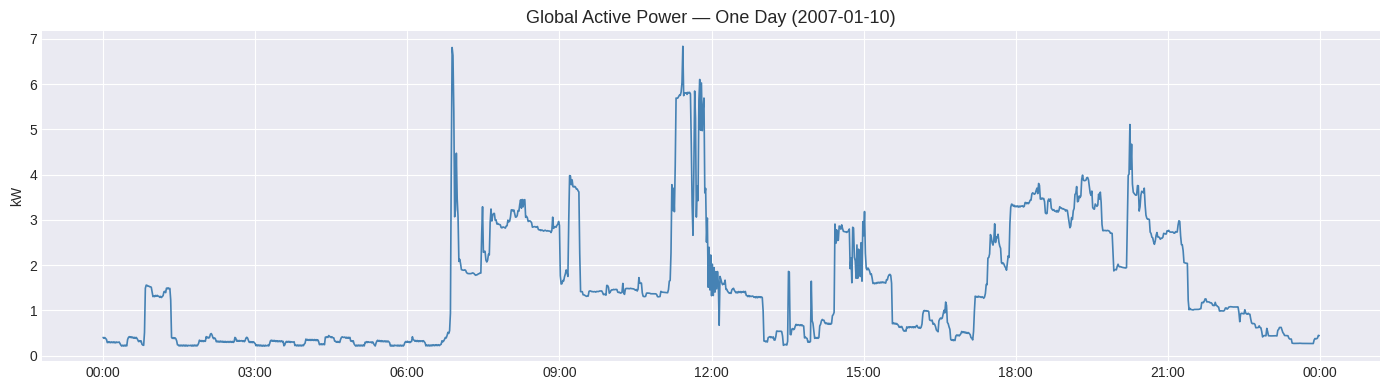

In [10]:
one_day = target['2007-01-10']

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(one_day.index, one_day.values, linewidth=1.2, color='steelblue')
ax.set_title('Global Active Power — One Day (2007-01-10)', fontsize=13)
ax.set_ylabel('kW')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.tight_layout()
plt.savefig('../outputs/plots/eda_one_day.png', dpi=120)
plt.show()

### 6b. One week

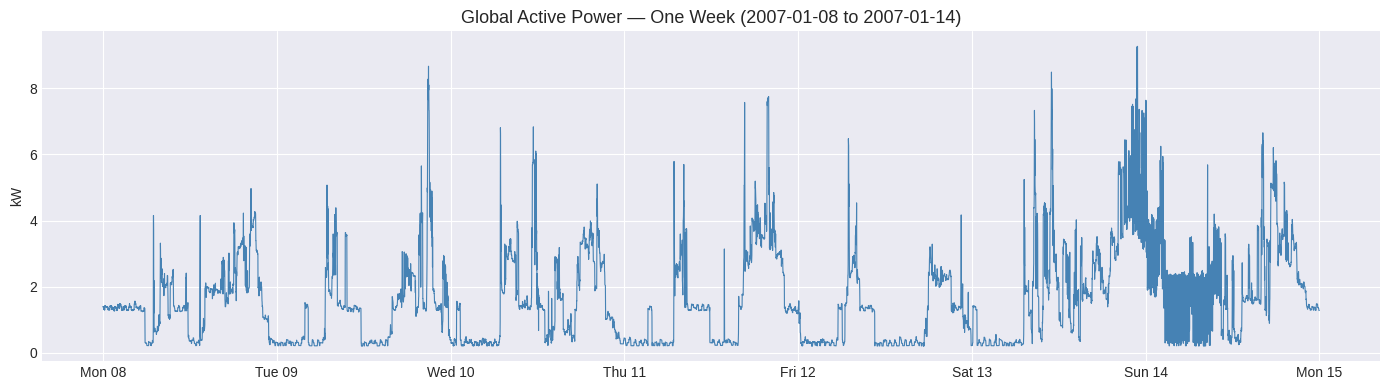

In [11]:
one_week = target['2007-01-08':'2007-01-14']

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(one_week.index, one_week.values, linewidth=0.8, color='steelblue')
ax.set_title('Global Active Power — One Week (2007-01-08 to 2007-01-14)', fontsize=13)
ax.set_ylabel('kW')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%a %d'))
plt.tight_layout()
plt.savefig('../outputs/plots/eda_one_week.png', dpi=120)
plt.show()

### 6c. Average by hour of day

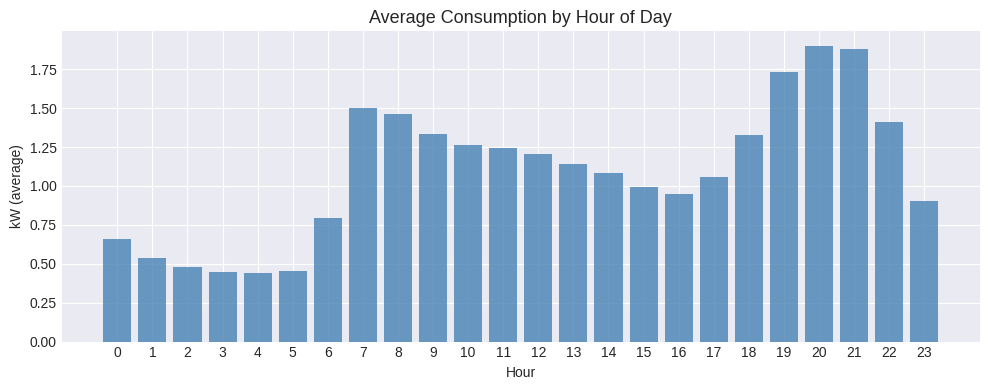

In [12]:
hourly_avg = target.groupby(target.index.hour).mean()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(hourly_avg.index, hourly_avg.values, color='steelblue', alpha=0.8)
ax.set_title('Average Consumption by Hour of Day', fontsize=13)
ax.set_xlabel('Hour')
ax.set_ylabel('kW (average)')
ax.set_xticks(range(24))
plt.tight_layout()
plt.savefig('../outputs/plots/eda_hourly_pattern.png', dpi=120)
plt.show()

### 6d. Weekday vs Weekend

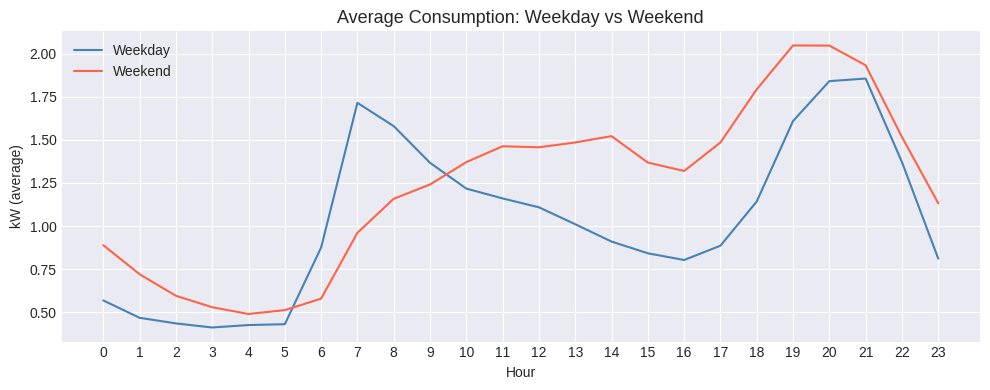

In [13]:
df_clean = df.dropna(subset=['Global_active_power']).copy()
df_clean['hour'] = df_clean.index.hour
df_clean['is_weekend'] = df_clean.index.dayofweek >= 5

weekday_avg = df_clean[~df_clean['is_weekend']].groupby('hour')['Global_active_power'].mean()
weekend_avg = df_clean[df_clean['is_weekend']].groupby('hour')['Global_active_power'].mean()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(weekday_avg.index, weekday_avg.values, label='Weekday', color='steelblue')
ax.plot(weekend_avg.index, weekend_avg.values, label='Weekend', color='tomato')
ax.set_title('Average Consumption: Weekday vs Weekend', fontsize=13)
ax.set_xlabel('Hour')
ax.set_ylabel('kW (average)')
ax.set_xticks(range(24))
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/plots/eda_weekday_vs_weekend.png', dpi=120)
plt.show()

### 6e. Distribution (histogram)

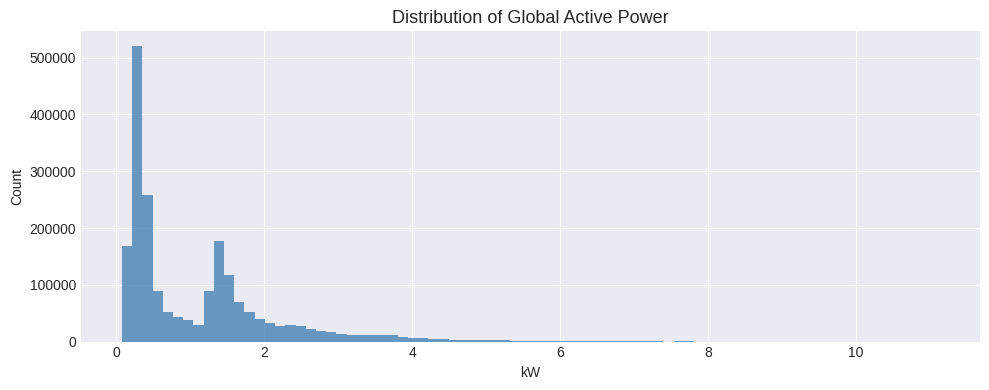

In [14]:
fig, ax = plt.subplots(figsize=(10, 4))
target.dropna().hist(bins=80, ax=ax, color='steelblue', alpha=0.8, edgecolor='none')
ax.set_title('Distribution of Global Active Power', fontsize=13)
ax.set_xlabel('kW')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('../outputs/plots/eda_histogram.png', dpi=120)
plt.show()

### 6f. Monthly average (seasonality)

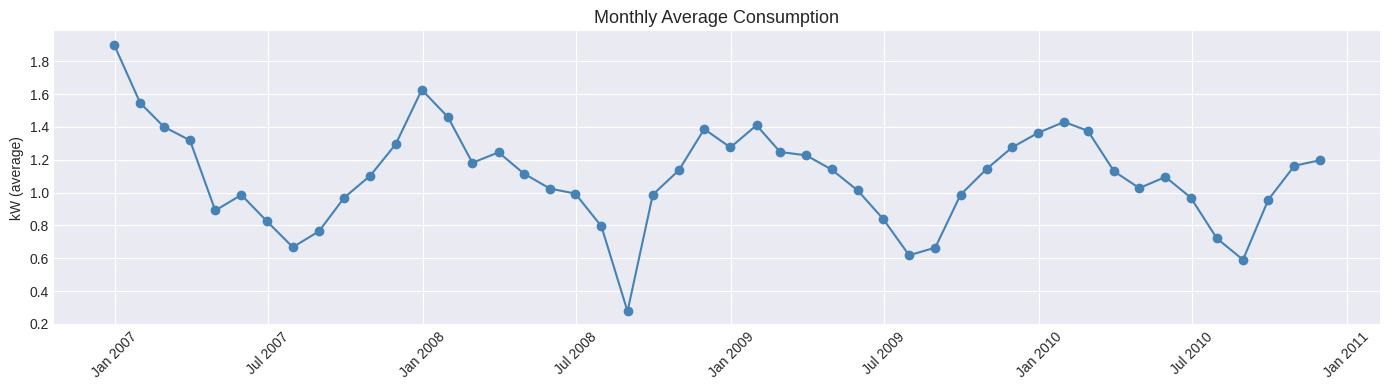

In [15]:
monthly_avg = target.resample('ME').mean()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(monthly_avg.index, monthly_avg.values, marker='o', color='steelblue', linewidth=1.5)
ax.set_title('Monthly Average Consumption', fontsize=13)
ax.set_ylabel('kW (average)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/plots/eda_monthly.png', dpi=120)
plt.show()

## 7. Key findings

| Question | Answer |
|---|---|
| What do we forecast? | `Global_active_power` (kW) — total household load |
| Sampling frequency? | 1 minute |
| Duration? | ~4 years |
| Missing values? | See table in section 3 |
| Resampling needed? | Yes — resample to **1 hour** for forecasting |
| Daily pattern? | Morning + evening peaks visible |
| Weekday vs Weekend? | Weekend consumption is more spread throughout the day |